In [1]:
import numpy as np

In [2]:
np.load('exact_data4_t.npy')
np.load('data4_x.npy')

array([9.00000000e-04, 1.08977500e-02, 2.08955000e-02, 3.08932500e-02,
       4.08910000e-02, 5.08887500e-02, 6.08865000e-02, 7.08842500e-02,
       8.08820000e-02, 9.08797500e-02, 1.00877500e-01, 1.10875250e-01,
       1.20873000e-01, 1.30870750e-01, 1.40868500e-01, 1.50866250e-01,
       1.60864000e-01, 1.70861750e-01, 1.80859500e-01, 1.90857250e-01,
       2.00855000e-01, 2.10852750e-01, 2.20850500e-01, 2.30848250e-01,
       2.40846000e-01, 2.50843750e-01, 2.60841500e-01, 2.70839250e-01,
       2.80837000e-01, 2.90834750e-01, 3.00832500e-01, 3.10830250e-01,
       3.20828000e-01, 3.30825750e-01, 3.40823500e-01, 3.50821250e-01,
       3.60819000e-01, 3.70816750e-01, 3.80814500e-01, 3.90812250e-01,
       4.00810000e-01, 4.10807750e-01, 4.20805500e-01, 4.30803250e-01,
       4.40801000e-01, 4.50798750e-01, 4.60796500e-01, 4.70794250e-01,
       4.80792000e-01, 4.90789750e-01, 5.00787500e-01, 5.10785250e-01,
       5.20783000e-01, 5.30780750e-01, 5.40778500e-01, 5.50776250e-01,
      

array([-2.00000000e+00, -1.97647059e+00, -1.95294118e+00, -1.92941176e+00,
       -1.90588235e+00, -1.88235294e+00, -1.85882353e+00, -1.83529412e+00,
       -1.81176471e+00, -1.78823529e+00, -1.76470588e+00, -1.74117647e+00,
       -1.71764706e+00, -1.69411765e+00, -1.67058824e+00, -1.64705882e+00,
       -1.62352941e+00, -1.60000000e+00, -1.57647059e+00, -1.55294118e+00,
       -1.52941176e+00, -1.50588235e+00, -1.48235294e+00, -1.45882353e+00,
       -1.43529412e+00, -1.41176471e+00, -1.38823529e+00, -1.36470588e+00,
       -1.34117647e+00, -1.31764706e+00, -1.29411765e+00, -1.27058824e+00,
       -1.24705882e+00, -1.22352941e+00, -1.20000000e+00, -1.17647059e+00,
       -1.15294118e+00, -1.12941176e+00, -1.10588235e+00, -1.08235294e+00,
       -1.05882353e+00, -1.03529412e+00, -1.01176471e+00, -9.88235294e-01,
       -9.64705882e-01, -9.41176471e-01, -9.17647059e-01, -8.94117647e-01,
       -8.70588235e-01, -8.47058824e-01, -8.23529412e-01, -8.00000000e-01,
       -7.76470588e-01, -

In [8]:
np.load('exact_data4_v.npy')

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [9]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy.utilities.lambdify import lambdify as lbd

x, nu, t = sp.symbols('x nu t')

phi = (sp.exp(-(x-4*t)**2/(4*nu*(t+1))) + 
       sp.exp(-(x-4*t-2*np.pi)**2 / (4*nu*(t+1))) )
phi_prime = phi.diff(x)

u = -2 * nu * (phi_prime/phi) + 4
u_lamb = lbd((t,x,nu), u)

# Set parameters for training data generation
nx = 256  # number of spatial grid points
L = 2.0 * np.pi  # length of the domain
dx = L / (nx - 1)  # spatial grid size
nu = 0.07  # viscosity
nt = 500  # number of time steps to compute
sigma = 0.1  # CFL limit
dt = sigma * dx**2 / nu  # time-step size

# Discretize the domain.
x = np.linspace(0.0, L, num=nx)

# Set the initial conditions.
t = 0.0
u0 = np.array([u_lamb(t, xi, nu) for xi in x])

# Compute the analytical solution.
#u_analytical = np.array([u_lamb(nt * dt, xi, nu) for xi in x])

# Compute the history of the analytical solution.
u_history = [np.array([u_lamb(n * dt, xi, nu) for xi in x])
                for n in range(nt)]
#Convert u_history into numpy array
#u_sol = np.array(u_history)

# Generate time values for saving
t_value = np.array([n*dt for n in range(nt)]) 
#m,n = u_sol.shape  # (m, n) = shape(t,u)
#print(m,n)
#print(t_value[499])

#u_exact = np.array([u_sol[i,:] for i in range(m)])

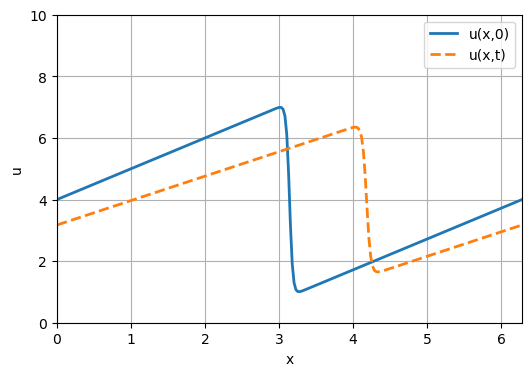

In [10]:
# Plot the analytical solution.
plt.figure(figsize=(6.0, 4.0))
plt.xlabel('x')
plt.ylabel('u')
plt.grid()
#plt.plot(x, u_sol[0,:], label='Initial',
 #           color='C0', linestyle='-', linewidth=2)
plt.plot(x, u_history[0], label='u(x,0)',
            color='C0', linestyle='-', linewidth=2)
#plt.plot(x, u_sol[-1,:], label='Analytical',
#            color='C1', linestyle='--', linewidth=2)
plt.plot(x, u_history[-200], label='u(x,t)',
            color='C1', linestyle='--', linewidth=2)
plt.legend()
plt.xlim(0.0, L)
plt.ylim(0.0, 10.0)

plt.show()